# 데이터 생성

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
! pip install seaborn

In [18]:
np.random.seed(42)

# 날짜 생성(2025-01-01 ~ 2025-12-31)
dates = pd.date_range('2025-01-01', '2025-12-31')

regions = ['서울','부산','대구','광주','인천',]
products = ['A','B','C','D']

# 가상의 매출 데이터 생성
data = {
    'date': np.random.choice(dates, 1000),
    'region': np.random.choice(regions, 1000),
    'product': np.random.choice(products, 1000),
    'sales': np.random.randint(100, 1000, 1000),     # 매출 100 ~ 1000만원
    'profit': np.random.randint(10, 200, 1000)     # 이익 10 ~ 200만원
}

# DataFrame 생성
df = pd.DataFrame(data)

# csv 저장
df.to_csv('./data/sales_data.csv', index=False, encoding='utf-8-sig')

print("sales_data.csv 파일이 생성됐습니다.")
print(df.head())

sales_data.csv 파일이 생성됐습니다.
        date region product  sales  profit
0 2025-04-13     대구       A    891     127
1 2025-12-15     대구       A    412      62
2 2025-09-28     서울       A    711      48
3 2025-04-17     부산       A    937      74
4 2025-03-13     부산       D    908     154


# csv 파일 읽어오기

In [5]:
df = pd.read_csv('./data/sales_data.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,region,product,sales,profit
0,2025-04-13,대구,A,891,127
1,2025-12-15,대구,A,412,62
2,2025-09-28,서울,A,711,48
3,2025-04-17,부산,A,937,74
4,2025-03-13,부산,D,908,154


# 총 매출액 분포(단일 변수 분포 확인)

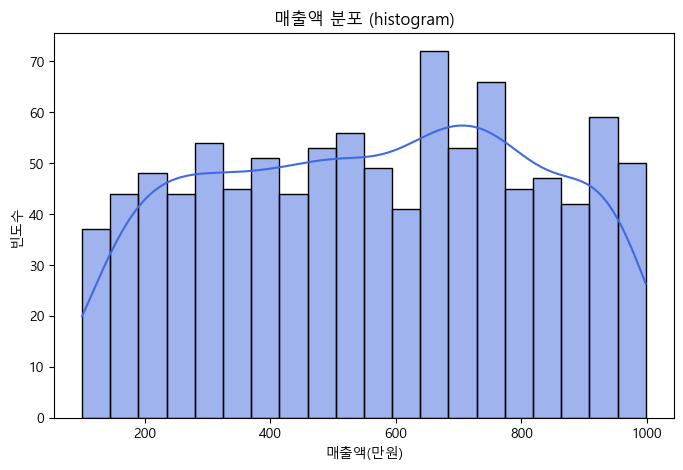

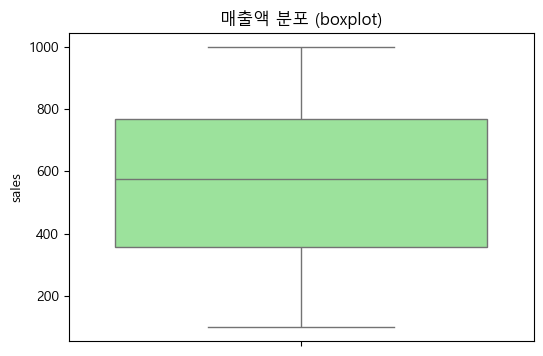

In [6]:
from matplotlib import font_manager, rc

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False      # 마니어스 부호 깨짐 방지

plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=20, kde=True, color='royalblue')
plt.title('매출액 분포 (histogram)')
plt.xlabel('매출액(만원)')
plt.ylabel('빈도수')

plt.figure(figsize=(6,4))
sns.boxplot(y='sales', data=df, color='lightgreen')
plt.title('매출액 분포 (boxplot)')
plt.show()

# 월 별 총 매출 추세 (시간 순서)

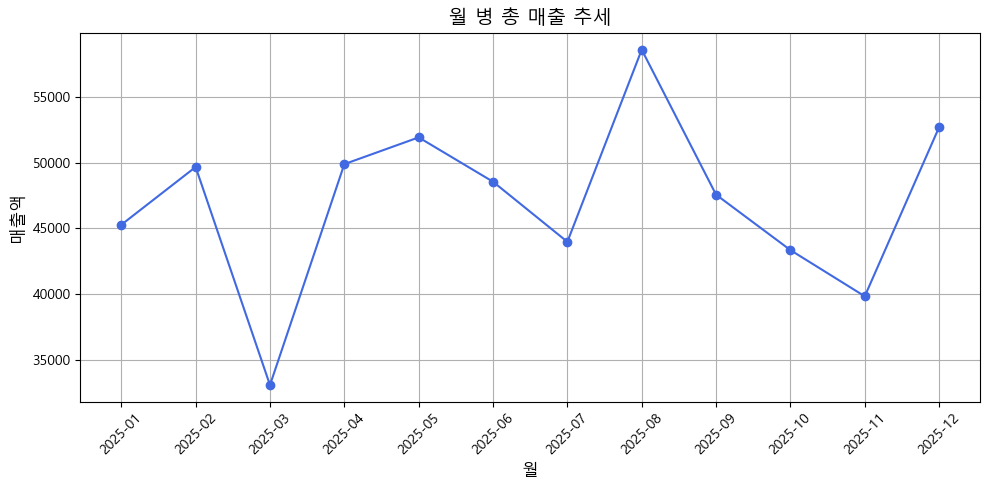

In [7]:
# date를 datetime 형식으로 변환
df['date'] = pd.to_datetime(df['date'])

# 월 단위 매출 집계
df_month = df.groupby(df['date'].dt.to_period('M')).sum(numeric_only=True)
df_month.index = df_month.index.astype(str)

# 그래프 크기 및 스타일 설정
plt.figure(figsize=(10,5))

# 선 그래프 생성
plt.plot(df_month.index, df_month['sales'], marker='o', color='royalblue')

# 그래프 제목, 축이름, 격자 설정
plt.title('월 병 총 매출 추세', fontsize=14)
plt.xlabel('월', fontsize=12)
plt.ylabel('매출액', fontsize=12)
plt.grid(True)   # 격자 표시

# x축 눈금 라벨 회전
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 지역별 평균 매출 비교 (범주형 비교)

AttributeError: 'Axes' object has no attribute 'se_title'

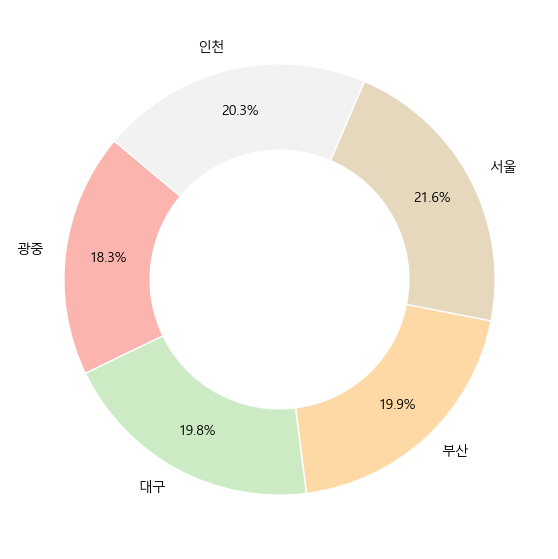

In [8]:
region_sales = df.groupby('region')['sales'].sum()
colors = plt.cm.Pastel1(np.linspace(0,1,len(region_sales)))

fig, ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = ax.pie(
    region_sales,
    labels = region_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.8,
    wedgeprops=dict(width=0.4, edgecolor='w')  # 도넛 모양
)

ax.se_title('지역별 총 매출 비중', fontsize=14, fontweight='bold')
plt.show()

# 제품별 매출 - 이익 상관관계 (두 변수 관계)

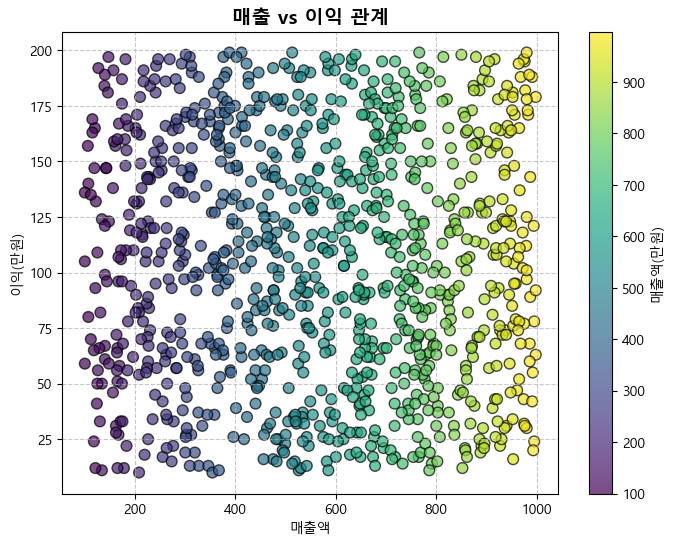

In [9]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['sales'], df['profit'],
                     c=df['sales'], cmap='viridis',
                     s=60, alpha=0.7, edgecolor='black')

plt.colorbar(scatter, label='매출액(만원)')
plt.title('매출 vs 이익 관계', fontsize=14, fontweight='bold')
plt.xlabel('매출액')
plt.ylabel('이익(만원)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

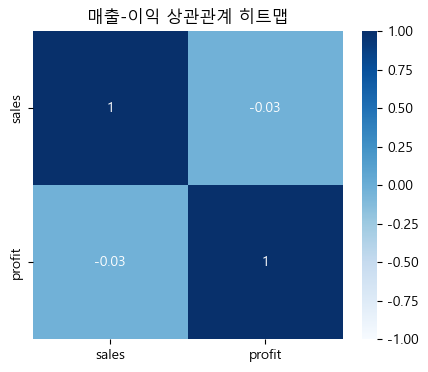

In [15]:
plt.figure(figsize=(5,4))
corr = df[['sales','profit']].corr()

sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1)

plt.title('매출-이익 상관관계 히트맵')
plt.show()

# 지역별 월간 매출 추세 (plotly 대화형 그래프)

In [32]:
! pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------  9.7/9.9 MB 66.9 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 66.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 19.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narw

In [10]:
import plotly.express as px

In [34]:
! pip install folium


   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]



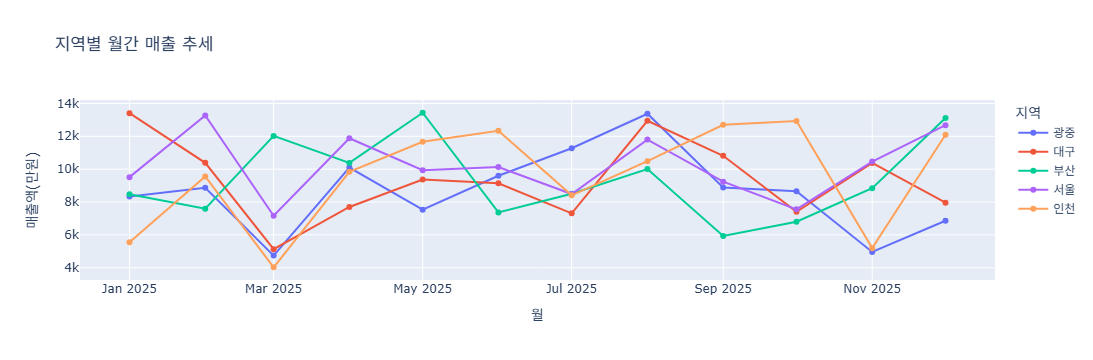

In [11]:
# 월별 + 지역별 총 매출
df['month'] = df['date'].dt.strftime('%Y-%m')
df_month_region = df.groupby(['month','region'])['sales'].sum().reset_index()

# Plotly 그래프
fig = px.line(
    df_month_region,
    x='month',
    y='sales',
    color='region',
    title='지역별 월간 매출 추세',
    markers=True
)

fig.update_layout(
    xaxis_title='월',
    yaxis_title='매출액(만원)',
    legend_title='지역'
)
fig.show()


# 지역별 평균 매출 지도 시각화(Folium)

In [12]:
import folium

In [19]:
# 지역별 평균 매출
region_sales = df.groupby('region')['sales'].mean()

# 지역별 위도/경도 표시
region_coords = {
    '서울' : [37.5665, 126.9780],
    '부산' : [35.1796, 196.0756],
    '대구' : [35.8714, 128.6014],
    '광주' : [35.1595, 126.8526],
    '인천' : [37.4563, 126.7052],
}

# 지도 생성
m = folium.Map(location=[36.5, 127.8], zoom_start=7)

# 각 지역에 CircleMarker 추가
for region, avg_sales in region_sales.items():
    folium.CircleMarker(
        location=region_coords[region],
        radius=avg_sales / 50,   # 매출 크기에 비례한 원의 크기
        color='blue',
        fill=True,
        fill_opacity=0.6,
        popup=f"{region}: {avg_sales:.1f}만원"
    ).add_to(m)

# 지도 저장 및 표시
m.save('sales_map.html')
m
    

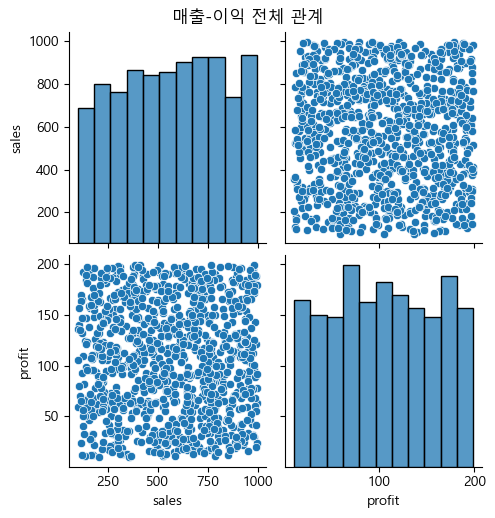

In [21]:
sns.pairplot(df[['sales', 'profit']], kind='scatter')
plt.suptitle('매출-이익 전체 관계', y=1.02)
plt.show()
# 각 조항별 산정도를 자동으로 그려주고,
# 데이터 간 상관 경향 및 분포를 빠르게 비교 확인 가능